In [3]:
import os
import sys

print(sys.executable)
print(os.getcwd())

C:\Users\andre\anaconda3\envs\bpu_attempt3\python.exe
C:\Users\andre\OneDrive\Desktop\Project_Folder_AT\unmodified_code_for_paper_before_github_v1_2026_02_12\src


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

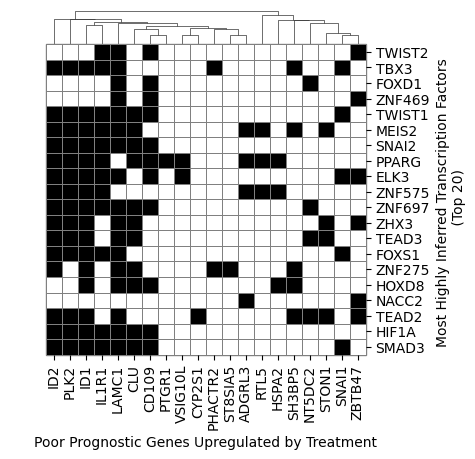

In [16]:
df = pd.read_csv(r'..\data\Integrated_meanRank.tsv',delimiter = '\t') #from CH3EA tool online
df = df.dropna(subset='Overlapping_Genes')
number_top_tfs = 20
df = df.head(number_top_tfs)

# Extract unique TFs and regulated genes
tf_list = df["TF"].tolist()
gene_set = set(g for genes in df["Overlapping_Genes"] for g in genes.split(","))
gene_list = sorted(gene_set)

# Create matrix
matrix = pd.DataFrame(0, index=tf_list, columns=gene_list)
for _, row in df.iterrows():
    tf = row["TF"]
    genes = row["Overlapping_Genes"].split(",")
    matrix.loc[tf, genes] = 1  # Mark connections
matrix = matrix[matrix.columns[::-1]]
# Generate clustered heatmap
g = sns.clustermap(matrix, cmap="Greys", linewidths=0.5, linecolor="gray", figsize=(4.5, 4.5), dendrogram_ratio=(0.1, 0.1),cbar_pos=None,
row_cluster = False, col_cluster = True ,xticklabels=1,yticklabels=1)

# Add black border around the heatmap
g.ax_heatmap.patch.set_edgecolor("grey")
g.ax_heatmap.patch.set_linewidth(1)

g.ax_heatmap.invert_xaxis()

plt.xlabel('Poor Prognostic Genes Upregulated by Treatment')
plt.ylabel(f'Most Highly Inferred Transcription Factors \n (Top {number_top_tfs})')

plt.savefig(r'..\results\figure_outputs_chea3' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()